<a href="https://colab.research.google.com/github/WithoutAnyTime/DataExploration/blob/main/zaj4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats


# Metoda najmniejszych kwadratów

Nachylenie (a): 0.5999999999999999
Wyraz wolny (b): 2.200000000000003


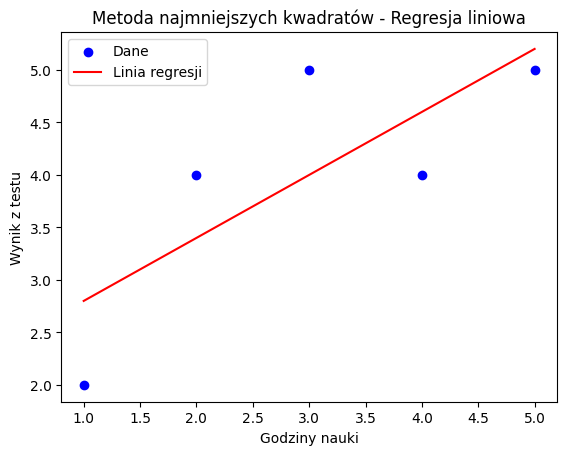

In [3]:
# Dane wejściowe: godziny nauki (x) i wyniki testu (y)
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

# Tworzenie macierzy projektującej X (dodajemy kolumnę jedynek)
X = np.vstack((x, np.ones(len(x)))).T

# Obliczanie współczynników metodą najmniejszych kwadratów
# beta = (X^T X)^(-1) X^T y
beta = np.linalg.inv(X.T @ X) @ X.T @ y

# Wyodrębnienie parametrów a (nachylenie) i b (wyraz wolny)
a, b = beta

print(f"Nachylenie (a): {a}")
print(f"Wyraz wolny (b): {b}")

# Rysowanie wykresu danych i dopasowanej linii regresji
plt.scatter(x, y, color='blue', label='Dane')
plt.plot(x, a * x + b, color='red', label='Linia regresji')
plt.xlabel('Godziny nauki')
plt.ylabel('Wynik z testu')
plt.legend()
plt.title('Metoda najmniejszych kwadratów - Regresja liniowa')
plt.show()

In [4]:
# Obliczanie reszt (błędów) modelu
residuals = y - (a * x + b)

# Obliczanie wariancji reszt
residual_variance = np.var(residuals, ddof=2)

# Obliczanie macierzy kowariancji parametrów
XTX_inv = np.linalg.inv(X.T @ X)
param_covariance_matrix = residual_variance * XTX_inv

# Błędy standardowe parametrów a i b
param_errors = np.sqrt(np.diag(param_covariance_matrix))

error_a, error_b = param_errors

error_a, error_b

(np.float64(0.28284271247461895), np.float64(0.9380831519646857))

In [5]:
# Obliczanie współczynnika korelacji Pearsona z macierzy projektującej X i wektora y
# Współczynnik korelacji Pearsona: r = cov(X, y) / (std(X) * std(y))

# Obliczanie średnich
mean_x = np.mean(x)
mean_y = np.mean(y)

# Obliczanie kowariancji
cov_xy = np.sum((x - mean_x) * (y - mean_y)) / (len(x) - 1)

# Obliczanie odchyleń standardowych
std_x = np.std(x, ddof=1)
std_y = np.std(y, ddof=1)

# Obliczanie współczynnika korelacji Pearsona
pearson_coefficient = cov_xy / (std_x * std_y)

pearson_coefficient

np.float64(0.7745966692414834)

# Zadanie 1

Wykorzystując `np.random.normal`, wygeneruj dane testowe (1000 punktów na płaszczyźnie w zależnosci liniowej między x i y) , do których zastosuj metodę najmniejszych kwadratów (możesz użyć **stats.linregres, scipy.optimize.curve_fit, numpy.polyfit**).
- Znajdź parametry prostej $y = a \cdot x + b$ .


Nachylenie (a): 2.0070379476143927
Wyraz wolny (b): -0.013014077418245479


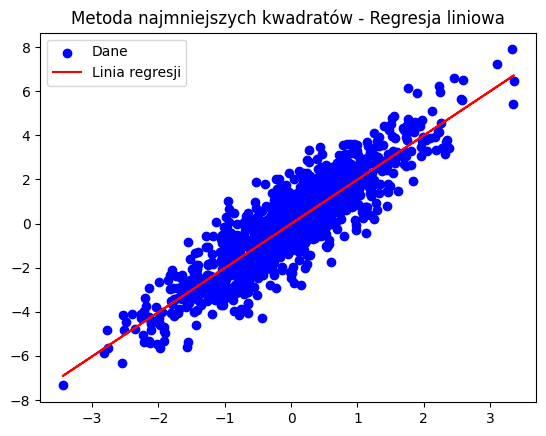

In [9]:
x=np.random.normal(0,1,1000)
y=2*x + np.random.normal(0,1,1000)
X = np.vstack((x, np.ones(len(x)))).T
beta = np.linalg.inv(X.T @ X) @ X.T @ y
a, b = beta
print(f"Nachylenie (a): {a}")
print(f"Wyraz wolny (b): {b}")

# Rysowanie wykresu danych i dopasowanej linii regresji
plt.scatter(x, y, color='blue', label='Dane')
plt.plot(x, a * x + b, color='red', label='Linia regresji')
plt.legend()
plt.title('Metoda najmniejszych kwadratów - Regresja liniowa')
plt.show()

# Zadanie 2

Wczytaj dane z pliku **LungDisease.csv** do DataFrame za pomocą biblioteki `pandas`. Dane te zawierają informacje o liczbie lat, przez które pracownik był narażony na pył bawełniany (**Exposure**), oraz o miarze pojemności płuc (**PEFR** - szczytowy przepływ wydechowy).

- Następnie, używając biblioteki matplotlib lub seaborn, stwórz wykres punktowy, na którym na osi x znajdzie się zmienna **Exposure**, a na osi y zmienna **PEFR**.

- Po stworzeniu wykresu, oblicz współczynnik korelacji Pearsona między **Exposure** a **PEFR**, aby ilościowo określić siłę i kierunek zależności między tymi zmiennymi.

- Na koniec, dopasuj prostą regresji liniowej do danych, aby zobaczyć, jak **PEFR** zmienia się w zależności od **Exposure**. Wyświetl wykres z dopasowaną prostą regresji

- Zastanów się, czy na wykresie punktowym widać wyraźny trend lub wzorzec. Czy PEFR rośnie czy maleje wraz z Exposure? Czy są jakieś odstające punkty lub nietypowe dane?

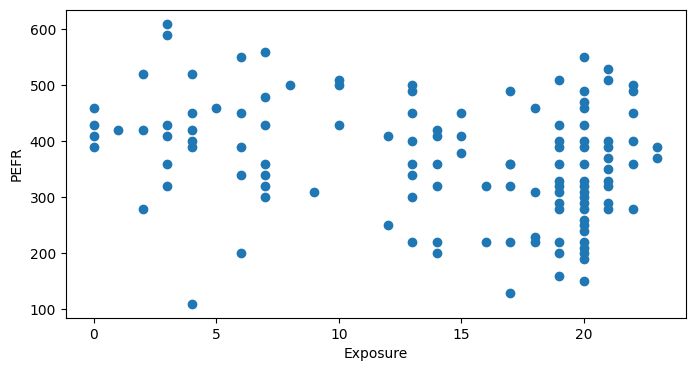

In [17]:
LungDisease = pd.read_csv('LungDisease.csv')
plt.figure(figsize=(8, 4))
plt.plot(LungDisease['Exposure'], LungDisease['PEFR'], 'o')
plt.xlabel('Exposure')
plt.ylabel('PEFR')
plt.show()

In [18]:
mean_exp = np.mean(LungDisease['Exposure'])
mean_PEFR = np.mean(LungDisease['PEFR'])

cov_exp_PEFR = np.sum((LungDisease['Exposure'] - mean_exp) * (LungDisease['PEFR'] - mean_PEFR)) / (len(LungDisease['Exposure']) - 1)

std_exp = np.std(LungDisease['Exposure'], ddof=1)
std_PEFR = np.std(LungDisease['PEFR'], ddof=1)

p_coeff = cov_exp_PEFR / (std_exp * std_PEFR)

p_coeff

np.float64(-0.27702170106840723)

Nachylenie (a): -4.184576485461444
Wyraz wolny (b): 424.58280657395693


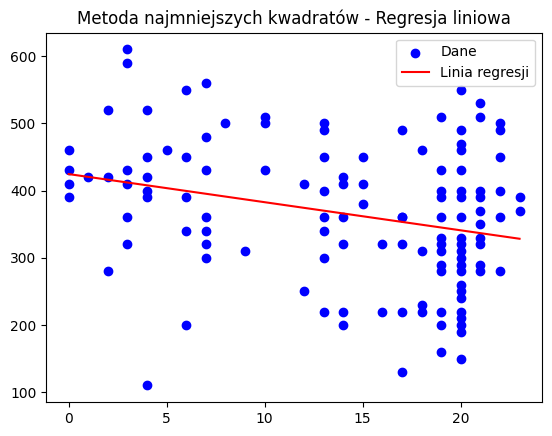

In [20]:
X = np.vstack((LungDisease['Exposure'], np.ones(len(LungDisease['Exposure'])))).T
beta = np.linalg.inv(X.T @ X) @ X.T @ LungDisease['PEFR']
a, b = beta
print(f"Nachylenie (a): {a}")
print(f"Wyraz wolny (b): {b}")

plt.scatter(LungDisease['Exposure'], LungDisease['PEFR'], color='blue', label='Dane')
plt.plot(LungDisease['Exposure'], a * LungDisease['Exposure'] + b, color='red', label='Linia regresji')
plt.legend()
plt.title('Metoda najmniejszych kwadratów - Regresja liniowa')
plt.show()

# Zadanie 3

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.

3. **Dopasuj funkcje liniowe:**
   - Dla każdej pary `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4` dopasuj funkcję liniową w postaci $y = a \cdot x + b$.
   - Oblicz współczynniki `a` i `b` wraz z błędami dla każdej pary.

4. **Oblicz współczynnik korelacji:**
   - Oblicz współczynnik korelacji Pearsona dla każdej pary `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.



In [26]:
anscombe = pd.read_csv('anscombe.csv', skiprows=1)
anscombe.columns = ["x1", "y1", "x2", "y2", "x3", "y3", "x4", "y4"]
anscombe

,x1,y1,x2,y2,x3,y3,x4,y4
0,10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
1,8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
2,13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
3,9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
4,11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
5,14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6,6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
7,4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50
8,12.0,10.84,12.0,9.13,12.0,8.15,8.0,5.56
9,7.0,4.82,7.0,7.26,7.0,6.42,8.0,7.91


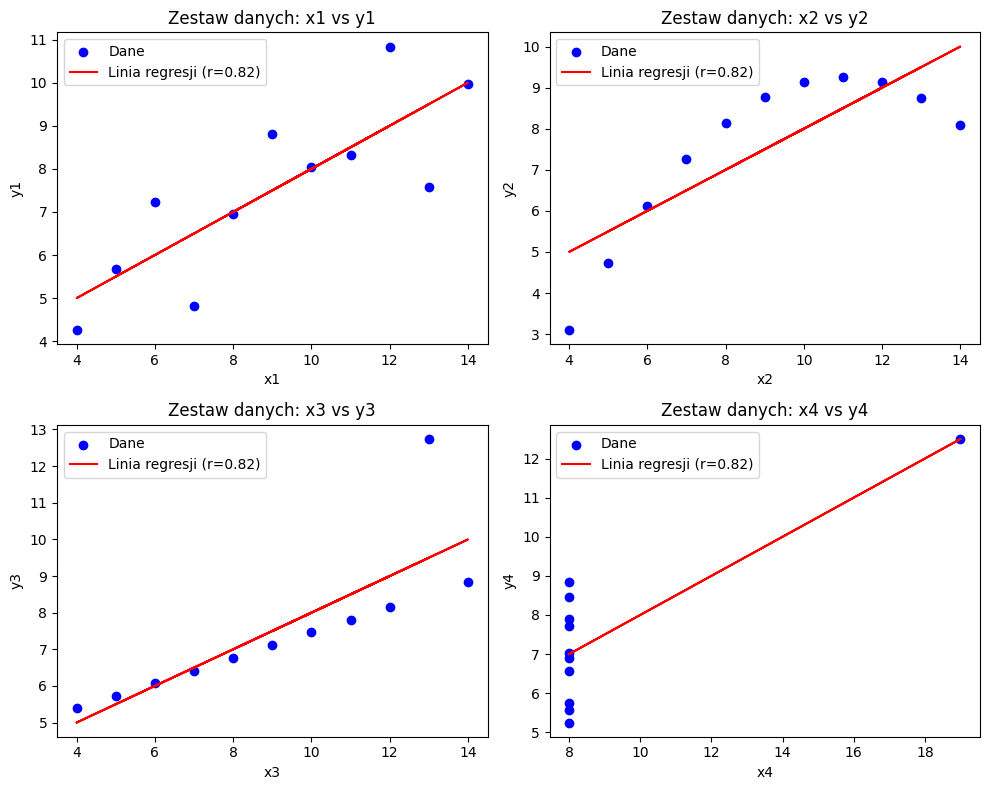

Współczynniki korelacji Pearsona:
Korelacja między x1 a y1: 0.8164
Korelacja między x2 a y2: 0.8162
Korelacja między x3 a y3: 0.8163
Korelacja między x4 a y4: 0.8165


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
data_sets = [('x1', 'y1'), ('x2', 'y2'), ('x3', 'y3'), ('x4', 'y4')]
for i, (x_col, y_col) in enumerate(data_sets):
    x_data = anscombe[x_col]
    y_data = anscombe[y_col]
    axes[i].scatter(x_data, y_data, color='blue', label='Dane')
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'Zestaw danych: {x_col} vs {y_col}')
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    axes[i].plot(x_data, slope * x_data + intercept, color='red', label=f'Linia regresji (r={r_value:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()
print("Współczynniki korelacji Pearsona:")
for x_col, y_col in data_sets:
    correlation = anscombe[x_col].corr(anscombe[y_col], method='pearson')
    print(f"Korelacja między {x_col} a {y_col}: {correlation:.4f}")